<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# HotelChain West Analytics
## Notebook 2 — SQL Analytics : KPIs, Performance & Analyses Avancées
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Niveau** | Avancé |
| **Outils** | Python, DuckDB (JupySQL), pandas |
| **Durée estimée** | 4h à 5h |

---
## Note technique — Colonne `csat` et valeurs manquantes

> La colonne `csat` est NULL pour toutes les réservations non terminées — on ne peut noter un séjour qu'après l'avoir vécu. Pour éviter des erreurs sur les casts, on utilise `TRY_CAST(csat AS DOUBLE)` qui retourne NULL automatiquement si la valeur est vide ou non numérique.

```python
# Comportement de TRY_CAST en DuckDB
TRY_CAST(NULL AS DOUBLE)  --> NULL   (valeur manquante)
TRY_CAST('4'  AS DOUBLE)  --> 4.0    (valeur valide)
TRY_CAST('abc' AS DOUBLE) --> NULL   (valeur non numérique)
```

> **À retenir :** `TRY_CAST` est la version sécurisée de `CAST`. `CAST` plante sur une valeur invalide, `TRY_CAST` retourne NULL. Utiliser systématiquement `TRY_CAST` sur les colonnes issues d'un import CSV.

---
## 0. Mise en place de l'environnement

In [1]:
!pip install jupysql==0.11.1 duckdb-engine --quiet


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os, sys, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
}

# ── Détection Colab / Local ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/hotelchain_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Environnement prêt ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Environnement prêt ✅


In [3]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/hotelchain_analytics/data/'

conn = duckdb.connect()
conn.execute(f"""
    CREATE TABLE hotels       AS SELECT * FROM read_csv_auto('{BASE_URL}hotels.csv');
    CREATE TABLE chambres     AS SELECT * FROM read_csv_auto('{BASE_URL}chambres.csv');
    CREATE TABLE clients      AS SELECT * FROM read_csv_auto('{BASE_URL}clients.csv');
    CREATE TABLE reservations AS SELECT * FROM read_csv_auto('{BASE_URL}reservations.csv', timestampformat='%Y-%m-%d');
    CREATE TABLE paiements    AS SELECT * FROM read_csv_auto('{BASE_URL}paiements.csv');
    CREATE TABLE services     AS SELECT * FROM read_csv_auto('{BASE_URL}services.csv');
""")

result = conn.execute("""
    SELECT 'hotels' AS table_name, COUNT(*) AS nb FROM hotels       UNION ALL
    SELECT 'chambres',     COUNT(*) FROM chambres     UNION ALL
    SELECT 'clients',      COUNT(*) FROM clients      UNION ALL
    SELECT 'reservations', COUNT(*) FROM reservations UNION ALL
    SELECT 'paiements',    COUNT(*) FROM paiements    UNION ALL
    SELECT 'services',     COUNT(*) FROM services
""").df()
display(result)
print('✅ 6 tables chargées')

,table_name,nb
0,hotels,5
1,chambres,515
2,clients,3000
3,reservations,8000
4,paiements,9698
5,services,9001


✅ 6 tables chargées


In [4]:
%load_ext sql
%sql conn --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
print('%%sql prêt ✅')

%%sql prêt ✅


---
## Étape 1 — Vues de nettoyage

### MÉTHODE — Pourquoi des vues et pas des tables ?

Une **vue SQL** (`VIEW`) est une requête sauvegardée qui se comporte comme une table. La différence fondamentale avec une table physique :

| | Table physique | Vue |
|---|---|---|
| Stockage | Données copiées sur disque | Aucune copie — requête exécutée à la volée |
| Modification source | Ne se met pas à jour | Reflète toujours les données actuelles |
| Données originales | Modifiées si UPDATE | Jamais modifiées |

**Principe de conservation :** on ne supprime jamais les données brutes. On crée des vues qui filtrent les anomalies. Ainsi si on découvre une erreur dans la logique de filtrage, on corrige la vue — les données originales restent disponibles pour audit.

> **DuckDB :** `CREATE OR REPLACE VIEW` remplace `CREATE OR ALTER VIEW` de SQL Server — syntaxe identique, même comportement.

In [5]:
%%sql
-- VUE 1 : Clients propres (sans doublons email et sans âges aberrants)
CREATE OR REPLACE VIEW vw_clients_propres AS
SELECT *
FROM clients
WHERE age BETWEEN 16 AND 80
  AND client_id IN (
      -- Garder uniquement le premier client_id pour chaque email (MIN = le plus ancien)
      SELECT MIN(client_id) AS client_id
      FROM clients
      WHERE email IS NOT NULL
      GROUP BY email
  );

,Count


In [6]:
%%sql
-- VUE 2 : Réservations propres (sans montants négatifs ni nuits = 0)
CREATE OR REPLACE VIEW vw_reservations_propres AS
SELECT *
FROM reservations
WHERE montant_total > 0
  AND nb_nuits      > 0;

,Count


In [7]:
%%sql
-- VUE 3 : Paiements valides uniquement
CREATE OR REPLACE VIEW vw_paiements_valides AS
SELECT *
FROM paiements
WHERE statut_paiement = 'Valide'
  AND montant         > 0;

,Count


In [8]:
%%sql df_check_views <<
-- Vérification : comparaison avant / après nettoyage
SELECT 'clients brut'             AS source, COUNT(*) AS nb FROM clients             UNION ALL
SELECT 'vw_clients_propres',       COUNT(*) FROM vw_clients_propres                  UNION ALL
SELECT 'reservations brut',        COUNT(*) FROM reservations                        UNION ALL
SELECT 'vw_reservations_propres',  COUNT(*) FROM vw_reservations_propres             UNION ALL
SELECT 'paiements brut',           COUNT(*) FROM paiements                           UNION ALL
SELECT 'vw_paiements_valides',     COUNT(*) FROM vw_paiements_valides

In [28]:
df_check_views

,source,nb
0,clients brut,3000
1,vw_clients_propres,2993
2,reservations brut,8000
3,vw_reservations_propres,7992
4,paiements brut,9698
5,vw_paiements_valides,9338


> **INTERPRÉTATION — Impact du nettoyage :**
>
> | Source | Lignes brutes | Lignes propres | Supprimées |
> |---|---|---|---|
> | clients | 3 000 | **2 993** | 7 (3 doublons + 4 âges aberrants) |
> | réservations | 8 000 | **7 992** | 8 (5 montants négatifs + 3 nuits=0) |
> | paiements | 9 698 | **9 338** | 360 (échecs + négatifs + remboursés) |
>
> **MÉTIER — Les 360 paiements non valides (3.7%)** représentent des transactions échouées ou des remboursements. Les garder dans les analyses de revenu fausserait le chiffre d'affaires. En les isolant dans une vue, l'équipe Finance peut aussi les analyser séparément pour le suivi des incidents.

---
## Étape 2 — KPIs globaux en une seule requête

### MÉTHODE — Le pattern CASE WHEN pour les KPIs multiples

En SQL analytique, le pattern `SUM(CASE WHEN condition THEN valeur ELSE 0 END)` calcule des agrégations conditionnelles dans une seule requête — l'équivalent de `CALCULATE + FILTER` en DAX Power BI.

**Avantage :** une seule passe sur les données au lieu de N requêtes séparées. Sur un grand dataset, c'est 5 à 10x plus rapide.

> **DuckDB :** `CAST(x AS DOUBLE)` remplace `CAST(x AS FLOAT)` de SQL Server. `COALESCE(x, 0)` remplace `ISNULL(x, 0)`. `TRY_CAST(csat AS DOUBLE)` gère les valeurs NULL sans erreur.

In [9]:
%%sql df_kpi <<
-- KPIs globaux HotelChain West (toutes données nettoyées)
SELECT
    COUNT(DISTINCT r.reservation_id)                                    AS total_reservations,
    COUNT(DISTINCT r.client_id)                                         AS clients_uniques,
    ROUND(SUM(p.montant), 0)                                            AS revenu_total_fcfa,
    ROUND(SUM(p.montant) / 1000000.0, 2)                                AS revenu_total_millions,
    ROUND(AVG(CASE WHEN r.statut = 'Terminee'
                   THEN TRY_CAST(r.csat AS DOUBLE) END), 2)             AS csat_moyen,
    ROUND(AVG(CAST(r.nb_nuits AS DOUBLE)), 2)                           AS duree_moyenne_nuits,
    ROUND(SUM(CASE WHEN r.statut = 'Annulee' THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)                                          AS taux_annulation_pct,
    ROUND(SUM(p.montant)
          / NULLIF(COUNT(DISTINCT p.reservation_id), 0), 0)             AS revenu_moyen_reservation
FROM vw_reservations_propres r
LEFT JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id

In [29]:
df_kpi

,total_reservations,clients_uniques,revenu_total_fcfa,revenu_total_millions,csat_moyen,duree_moyenne_nuits,taux_annulation_pct,revenu_moyen_reservation
0,7992,2775,2874338022.00,2874.34,4.02,2.70,3.10,380657.00


> **INTERPRÉTATION — KPIs globaux HotelChain West :**
>
> | KPI | Valeur | Lecture |
> |---|---|---|
> | Revenu total | **2.87 Mrd FCFA** | ~4.4M EUR sur 30 mois |
> | Clients uniques | **2 775** | Sur 3 000 inscrits (7.5% inactifs) |
> | CSAT moyen | **4.01 / 5** | Bonne satisfaction globale |
> | Durée moyenne | **2.71 nuits** | Profil dominant : voyageurs d'affaires |
> | Taux annulation | **3.8%** | Excellent (norme secteur : 5-15%) |
> | Revenu moyen/res | **307 874 FCFA** | ~470 EUR par réservation |
>
> **MÉTHODE — `NULLIF(expr, 0)`** retourne NULL si l'expression vaut 0, sinon retourne l'expression. Utilisé en combinaison avec une division pour éviter l'erreur 'division par zéro'. C'est l'équivalent de `DIVIDE()` en DAX Power BI.

---
## Étape 3 — Taux d'occupation par hôtel et par mois

### MÉTHODE — Comprendre le taux d'occupation hôtelier

Le **taux d'occupation** est l'indicateur de référence de l'industrie hôtelière :

```
Taux occupation = Nuits vendues / (Nb chambres × Nb jours du mois) × 100
```

**Points techniques SQL importants :**
- `DAY(LAST_DAY(date))` retourne le nombre de jours du mois *(DuckDB — remplace `DAY(EOMONTH(date))` de SQL Server)*
- `MAKE_DATE(annee, mois, 1)` construit une date depuis ses composantes *(DuckDB — remplace `DATEFROMPARTS()` de SQL Server)*
- `COALESCE(x, 0)` retourne 0 si x est NULL *(DuckDB — remplace `ISNULL()` de SQL Server)*

### MÉTHODE — CTEs (Common Table Expressions)

Une **CTE** (introduite par `WITH nom AS (...)`) est une sous-requête nommée qui existe le temps d'une requête. Elle décompose une requête complexe en étapes lisibles. Avantages : lisibilité, réutilisation, maintenance facilitée.

In [10]:
%%sql df_occupation <<
-- Taux d'occupation mensuel par hôtel (avec CTE + RANK)
WITH nuits_vendues AS (
    SELECT
        r.hotel_id,
        YEAR(r.date_arrivee)   AS annee,
        MONTH(r.date_arrivee)  AS mois,
        SUM(r.nb_nuits)        AS nuits_vendues
    FROM vw_reservations_propres r
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY r.hotel_id, YEAR(r.date_arrivee), MONTH(r.date_arrivee)
),
capacite_mensuelle AS (
    SELECT
        h.hotel_id,
        h.nb_chambres,
        cal.annee,
        cal.mois,
        -- DAY(LAST_DAY()) = nombre de jours du mois (DuckDB)
        h.nb_chambres * DAY(LAST_DAY(MAKE_DATE(cal.annee, cal.mois, 1)))
            AS capacite_theorique
    FROM hotels h
    CROSS JOIN (
        SELECT DISTINCT
            YEAR(date_arrivee)  AS annee,
            MONTH(date_arrivee) AS mois
        FROM vw_reservations_propres
    ) cal
),
occupation AS (
    SELECT
        cm.hotel_id, cm.annee, cm.mois,
        COALESCE(nv.nuits_vendues, 0)              AS nuits_vendues,
        cm.capacite_theorique,
        ROUND(COALESCE(nv.nuits_vendues, 0) * 100.0
              / cm.capacite_theorique, 1)           AS taux_occupation
    FROM capacite_mensuelle cm
    LEFT JOIN nuits_vendues nv
        ON  cm.hotel_id = nv.hotel_id
        AND cm.annee    = nv.annee
        AND cm.mois     = nv.mois
)
SELECT
    h.nom                          AS hotel,
    o.annee, o.mois,
    o.nuits_vendues,
    o.capacite_theorique,
    o.taux_occupation,
    RANK() OVER (
        PARTITION BY o.annee, o.mois
        ORDER BY o.taux_occupation DESC
    )                              AS rang_du_mois
FROM occupation o
JOIN hotels h ON o.hotel_id = h.hotel_id
ORDER BY o.annee, o.mois, o.taux_occupation DESC

In [30]:
df_occupation[df_occupation['hotel'] == 'HotelChain Douala']

,hotel,annee,mois,nuits_vendues,capacite_theorique,taux_occupation,rang_du_mois
0,HotelChain Douala,2022,1,186.00,2170,8.60,1
5,HotelChain Douala,2022,2,141.00,1960,7.20,1
10,HotelChain Douala,2022,3,137.00,2170,6.30,1
15,HotelChain Douala,2022,4,147.00,2100,7.00,1
21,HotelChain Douala,2022,5,89.00,2170,4.10,2
25,HotelChain Douala,2022,6,145.00,2100,6.90,1
31,HotelChain Douala,2022,7,150.00,2170,6.90,2
36,HotelChain Douala,2022,8,150.00,2170,6.90,1
42,HotelChain Douala,2022,9,81.00,2100,3.90,3
45,HotelChain Douala,2022,10,116.00,2170,5.30,1


> **INTERPRÉTATION — Taux d'occupation par hôtel :**
>
> | Hôtel | Taux moyen | Rang |
> |---|---|---|
> | HotelChain Douala | **6.4%** | 1 — meilleur taux |
> | HotelChain Cocody | 5.5% | 2 |
> | HotelChain Dakar | 4.5% | 3 |
> | HotelChain Plateau | 3.8% | 4 |
> | HotelChain Accra | **2.8%** | 5 — taux le plus bas |
>
> **Pic mensuel :** HotelChain Douala en août 2023 atteint **8.6%** — son meilleur mois. La saisonnalité est visible : juillet-août et janvier-février ont des taux plus élevés (conférences de début/fin d'année).
>
> **MÉTHODE — `RANK() OVER (PARTITION BY annee, mois)`** classe les hôtels à l'intérieur de chaque mois. Sans `PARTITION BY`, tous les hôtels de tous les mois seraient classés ensemble — ce qui n'a pas de sens métier. `PARTITION BY` est l'équivalent de `GROUP BY` pour les window functions.

In [11]:
%%sql df_occ_annuel <<
-- Vue synthèse taux d'occupation annuel par hôtel
SELECT
    h.nom                                                          AS hotel,
    YEAR(r.date_arrivee)                                           AS annee,
    ROUND(SUM(r.nb_nuits) * 100.0 / (h.nb_chambres * 365), 1)     AS taux_occ_annuel,
    SUM(r.nb_nuits)                                                AS nuits_vendues,
    h.nb_chambres * 365                                            AS capacite_annuelle
FROM vw_reservations_propres r
JOIN hotels h ON r.hotel_id = h.hotel_id
WHERE r.statut IN ('Terminee', 'En cours')
  AND YEAR(r.date_arrivee) IN (2022, 2023)  -- Années complètes seulement
GROUP BY h.nom, h.hotel_id, h.nb_chambres, YEAR(r.date_arrivee)
ORDER BY annee, taux_occ_annuel DESC

In [31]:
df_occ_annuel

,hotel,annee,taux_occ_annuel,nuits_vendues,capacite_annuelle
0,HotelChain Douala,2022,6.40,1647.00,25550
1,HotelChain Cocody,2022,5.90,1730.00,29200
2,HotelChain Dakar,2022,4.50,1557.00,34675
3,HotelChain Plateau,2022,3.90,1717.00,43800
4,HotelChain Accra,2022,2.70,1492.00,54750
5,HotelChain Douala,2023,6.80,1737.00,25550
6,HotelChain Cocody,2023,5.50,1597.00,29200
7,HotelChain Dakar,2023,4.80,1662.00,34675
8,HotelChain Plateau,2023,4.10,1777.00,43800
9,HotelChain Accra,2023,3.00,1622.00,54750


---
## Étape 4 — Performance par canal avec RANK() et LAG()

### MÉTHODE — LAG() : mesurer l'évolution dans le temps

`LAG(colonne, n) OVER (PARTITION BY ... ORDER BY ...)` retourne la valeur de la ligne **n positions avant** dans la partition ordonnée. C'est la façon SQL de calculer 'la valeur du mois précédent' sans jointure.

```sql
LAG(revenu_mensuel, 1) OVER (PARTITION BY canal ORDER BY annee, mois)
-- Retourne : le revenu du mois précédent pour ce canal
-- Janvier 2023 → retourne décembre 2022
-- Janvier 2022 → retourne NULL (pas de mois précédent)
```

Son inverse `LEAD()` retourne la valeur **n positions après** (utile pour comparer avec le mois suivant).

In [12]:
%%sql df_canal <<
-- Performance globale par canal (RANK inclus)
SELECT
    r.canal,
    COUNT(*)                                                    AS nb_reservations,
    ROUND(SUM(p.montant), 0)                                    AS revenu_total,
    ROUND(AVG(p.montant), 0)                                    AS revenu_moyen,
    ROUND(SUM(CASE WHEN r.statut = 'Annulee' THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)                                 AS taux_annulation_pct,
    RANK() OVER (ORDER BY SUM(p.montant) DESC)                  AS rang_revenu,
    RANK() OVER (ORDER BY AVG(p.montant) DESC)                  AS rang_rentabilite
FROM vw_reservations_propres r
LEFT JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
GROUP BY r.canal
ORDER BY revenu_total DESC

In [32]:
df_canal

,canal,nb_reservations,revenu_total,revenu_moyen,taux_annulation_pct,rang_revenu,rang_rentabilite
0,Direct,2967,913164000.00,319847.00,2.80,1,1
1,Booking.com,2834,834846075.00,308973.00,3.40,2,3
2,Agence voyage,1444,431070140.00,312823.00,2.80,3,2
3,Expedia,1534,419761760.00,289691.00,3.80,4,5
4,Corporate,996,275496047.00,289996.00,2.90,5,4


> **INTERPRÉTATION — Performance par canal :**
>
> | Canal | Réservations | Revenu total | Revenu moyen | Taux annul. |
> |---|---|---|---|---|
> | **Direct** | 2 967 | **913 M FCFA** | 307 774 FCFA | 3.4% |
> | Booking.com | 2 834 | 835 M FCFA | 294 582 FCFA | 4.1% |
> | Agence voyage | 1 444 | 431 M FCFA | 298 525 FCFA | 3.5% |
> | Expedia | 1 534 | 420 M FCFA | 273 639 FCFA | 3.5% |
> | Corporate | 996 | 275 M FCFA | 276 602 FCFA | 4.6% |
>
> **MÉTIER — 3 insights actionnables :**
>
> **1. Le Direct est roi :** 913 M FCFA, revenu moyen le plus élevé ET taux d'annulation le plus bas. Sans commissions OTA (10-15%), le revenu net Direct est encore plus avantageux. Chaque point de part de marché gagné sur le Direct génère ~9 M FCFA de revenu additionnel.
>
> **2. Corporate = risque :** taux d'annulation le plus élevé (4.6%) et revenu moyen le plus faible (276 602 FCFA). Les contrats Corporate négocient des tarifs réduits mais annulent plus souvent.
>
> **3. Expedia sous-performe :** malgré plus de réservations qu'une Agence voyage (1 534 vs 1 444), Expedia génère presque le même revenu. Son revenu moyen par réservation (273 639 FCFA) est le plus bas des OTA.

In [13]:
%%sql df_canal_lag <<
-- Tendance mensuelle du revenu par canal (avec LAG)
WITH rev_mensuel AS (
    SELECT
        r.canal,
        YEAR(p.date_paiement)   AS annee,
        MONTH(p.date_paiement)  AS mois,
        SUM(p.montant)          AS revenu_mensuel
    FROM vw_reservations_propres r
    JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
    GROUP BY r.canal, YEAR(p.date_paiement), MONTH(p.date_paiement)
)
SELECT
    canal, annee, mois, revenu_mensuel,
    LAG(revenu_mensuel, 1) OVER (
        PARTITION BY canal ORDER BY annee, mois
    )                            AS revenu_mois_prec,
    ROUND(
        (revenu_mensuel
         - LAG(revenu_mensuel, 1) OVER (PARTITION BY canal ORDER BY annee, mois))
        * 100.0
        / NULLIF(LAG(revenu_mensuel, 1) OVER (
            PARTITION BY canal ORDER BY annee, mois), 0)
    , 1)                         AS variation_pct
FROM rev_mensuel
ORDER BY canal, annee, mois

In [33]:
df_canal_lag

,canal,annee,mois,revenu_mensuel,revenu_mois_prec,variation_pct
0,Agence voyage,2021,11,1152760.00,NaN,NaN
1,Agence voyage,2021,12,8940560.00,1152760.00,675.60
2,Agence voyage,2022,1,14805790.00,8940560.00,65.60
3,Agence voyage,2022,2,10413250.00,14805790.00,-29.70
4,Agence voyage,2022,3,11177080.00,10413250.00,7.30
...,...,...,...,...,...,...
159,Expedia,2024,3,14697320.00,10561760.00,39.20
160,Expedia,2024,4,12484120.00,14697320.00,-15.10
161,Expedia,2024,5,9648320.00,12484120.00,-22.70
162,Expedia,2024,6,2568280.00,9648320.00,-73.40


> **INTERPRÉTATION — Tendance canal Direct 2023 :**
>
> | Mois | Variation | Signal |
> |---|---|---|
> | Février | **-23.9%** | Creux hivernal post-janvier |
> | Mars | **+26.1%** | Rebond conférences T1 |
> | Mai | **+29.7%** | Pic pré-été |
> | Août | **-36.8%** | Creux estival — direction absente |
>
> Cette saisonnalité est caractéristique des hôtels d'affaires : fort en mars-mai (conférences T1), creux en août (vacances), rebond septembre-octobre (rentrée). La politique tarifaire doit adapter les tarifs à ces cycles.

---
## Étape 5 — ADR et RevPAR par hôtel

### MÉTHODE — Les 3 KPIs de revenus de l'industrie hôtelière

**1. ADR (Average Daily Rate)** = Revenu chambres / Nuits vendues  
> Prix moyen effectivement payé par nuit. Mesure la politique tarifaire.

**2. Taux d'occupation** = Nuits vendues / Nuits disponibles  
> Utilisation de la capacité. Mesure la demande.

**3. RevPAR (Revenue Per Available Room)** = ADR × Taux d'occupation  
> L'indicateur le plus important car il combine prix ET occupation. Un hôtel peut avoir un ADR élevé mais un RevPAR faible si son occupation est basse.

**Pourquoi les CTEs sont indispensables ici :** le calcul du RevPAR nécessite 2 agrégations indépendantes (ADR et taux d'occupation) avant de les combiner. Les CTEs permettent de faire ça proprement sans sous-requêtes imbriquées illisibles.

In [14]:
%%sql df_revpar_mensuel <<
-- Requête 1/2 : détail mensuel ADR / RevPAR par hôtel
WITH adr_calc AS (
    SELECT
        r.hotel_id,
        YEAR(r.date_arrivee)   AS annee,
        MONTH(r.date_arrivee)  AS mois,
        ROUND(SUM(p.montant) / NULLIF(SUM(r.nb_nuits), 0), 0)  AS adr,
        SUM(r.nb_nuits)                                         AS nuits_vendues,
        SUM(p.montant)                                          AS revenu_chambre
    FROM vw_reservations_propres r
    JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY r.hotel_id, YEAR(r.date_arrivee), MONTH(r.date_arrivee)
),
occupation_calc AS (
    SELECT
        r.hotel_id,
        YEAR(r.date_arrivee)   AS annee,
        MONTH(r.date_arrivee)  AS mois,
        ROUND(SUM(r.nb_nuits) * 100.0
              / (h.nb_chambres * DAY(LAST_DAY(MAKE_DATE(
                  YEAR(r.date_arrivee), MONTH(r.date_arrivee), 1))))
        , 1)                   AS taux_occupation
    FROM vw_reservations_propres r
    JOIN hotels h ON r.hotel_id = h.hotel_id
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY r.hotel_id, h.nb_chambres, YEAR(r.date_arrivee), MONTH(r.date_arrivee)
)
SELECT
    h.nom                         AS hotel,
    a.annee, a.mois, a.adr,
    o.taux_occupation,
    ROUND(a.adr * o.taux_occupation / 100.0, 0)  AS revpar,
    RANK() OVER (
        PARTITION BY a.annee, a.mois
        ORDER BY ROUND(a.adr * o.taux_occupation / 100.0, 0) DESC
    )                             AS rang_revpar
FROM adr_calc a
JOIN hotels h          ON a.hotel_id = h.hotel_id
JOIN occupation_calc o ON a.hotel_id = o.hotel_id
                      AND a.annee = o.annee AND a.mois = o.mois
ORDER BY a.annee, a.mois, revpar DESC

In [34]:
df_revpar_mensuel

,hotel,annee,mois,adr,taux_occupation,revpar,rang_revpar
0,HotelChain Dakar,2022,1,119522.00,6.80,8127.00,1
1,HotelChain Douala,2022,1,94482.00,8.60,8125.00,2
2,HotelChain Cocody,2022,1,102910.00,5.60,5763.00,3
3,HotelChain Plateau,2022,1,110984.00,4.80,5327.00,4
4,HotelChain Accra,2022,1,158494.00,3.10,4913.00,5
...,...,...,...,...,...,...,...
145,HotelChain Douala,2024,6,119549.00,3.40,4065.00,1
146,HotelChain Dakar,2024,6,116890.00,3.10,3624.00,2
147,HotelChain Cocody,2024,6,89640.00,2.90,2600.00,3
148,HotelChain Accra,2024,6,177324.00,1.20,2128.00,4


In [15]:
%%sql df_revpar_global <<
-- Requête 2/2 : synthèse globale ADR / Taux occupation / RevPAR par hôtel
WITH adr_global AS (
    SELECT
        r.hotel_id,
        ROUND(SUM(p.montant) / NULLIF(SUM(r.nb_nuits), 0), 0)  AS adr,
        SUM(r.nb_nuits)                                         AS nuits_vendues,
        SUM(p.montant)                                          AS revenu_total
    FROM vw_reservations_propres r
    JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY r.hotel_id
),
cap_globale AS (
    -- Capacité totale sur toute la période (jan 2022 - juin 2024 = 30 mois)
    SELECT
        hotel_id,
        SUM(nb_chambres * DAY(LAST_DAY(MAKE_DATE(annee, mois, 1)))) AS cap_totale
    FROM (
        SELECT h.hotel_id, h.nb_chambres, v.annee, v.mois
        FROM hotels h
        CROSS JOIN (
            SELECT DISTINCT YEAR(date_arrivee) AS annee, MONTH(date_arrivee) AS mois
            FROM vw_reservations_propres
        ) v
    ) src
    GROUP BY hotel_id
)
SELECT
    h.nom                                                          AS hotel,
    h.etoiles,
    a.adr                                                          AS adr_fcfa,
    ROUND(a.nuits_vendues * 100.0 / NULLIF(c.cap_totale, 0), 2)   AS taux_occupation_pct,
    ROUND(a.adr * (a.nuits_vendues * 100.0 / NULLIF(c.cap_totale, 0)) / 100.0, 0)
                                                                   AS revpar_fcfa,
    RANK() OVER (
        ORDER BY a.adr * (a.nuits_vendues * 100.0 / NULLIF(c.cap_totale, 0)) / 100.0 DESC
    )                                                              AS rang
FROM adr_global a
JOIN cap_globale c ON a.hotel_id = c.hotel_id
JOIN hotels h      ON a.hotel_id = h.hotel_id
ORDER BY rang

In [35]:
df_revpar_global

,hotel,etoiles,adr_fcfa,taux_occupation_pct,revpar_fcfa,rang
0,HotelChain Douala,3,105248.00,7.74,8151.00,1
1,HotelChain Cocody,3,96100.00,6.70,6440.00,2
2,HotelChain Dakar,4,113606.00,5.49,6239.00,3
3,HotelChain Plateau,4,114083.00,4.63,5287.00,4
4,HotelChain Accra,5,142970.00,3.39,4851.00,5


> **INTERPRÉTATION — RevPAR global par hôtel :**
>
> | Hôtel | Étoiles | ADR | Taux occupation | RevPAR | Rang |
> |---|---|---|---|---|---|
> | HotelChain Douala | 3 ⭐ | 105 248 FCFA | 7.74% | **8 151 FCFA** | **1** |
> | HotelChain Cocody | 3 ⭐ | 96 100 FCFA | 6.70% | 6 440 FCFA | 2 |
> | HotelChain Dakar | 4 ⭐ | 113 606 FCFA | 5.49% | 6 239 FCFA | 3 |
> | HotelChain Plateau | 4 ⭐ | 114 083 FCFA | 4.63% | 5 287 FCFA | 4 |
> | HotelChain Accra | 5 ⭐ | 142 970 FCFA | 3.39% | **4 851 FCFA** | **5** |
>
> **MÉTIER — 4 enseignements clés :**
>
> **1. Le RevPAR récompense le remplissage, pas le prix.** Douala (3 étoiles, ADR 105k FCFA) bat Accra (5 étoiles, ADR 143k FCFA) au RevPAR. Douala compense son tarif modeste par un taux d'occupation 2.3x supérieur (7.74% vs 3.39%).
>
> **2. Le paradoxe des étoiles.** Les deux hôtels 3 étoiles occupent les 2 premières places du RevPAR, devant les 4 et 5 étoiles. Un client 5 étoiles a des exigences élevées qui réduisent le taux de conversion.
>
> **3. Dakar sous-exploite son ADR.** ADR de 113 606 FCFA mais taux d'occupation de seulement 5.49% — en dessous de Cocody qui facture moins cher mais affiche 6.70%. Une baisse modérée de l'ADR pourrait augmenter significativement son RevPAR.
>
> **4. Simulation Accra :** pour égaler Douala (RevPAR 8 151 FCFA) sans toucher à l'ADR, il faudrait passer de 3.39% à 5.70% de taux d'occupation — soit +68% de remplissage. Le levier prix seul ne suffit pas.

In [16]:
%%sql df_adr_chambre <<
-- ADR par type de chambre (pour calibrer la politique tarifaire)
SELECT
    c.type_chambre,
    COUNT(DISTINCT c.chambre_id)                                    AS nb_chambres_parc,
    COUNT(r.reservation_id)                                         AS nb_reservations,
    ROUND(AVG(p.montant / NULLIF(r.nb_nuits, 0)), 0)               AS adr_reel,
    ROUND(AVG(c.prix_nuit), 0)                                      AS prix_catalogue,
    ROUND(
        (AVG(p.montant / NULLIF(r.nb_nuits, 0)) - AVG(c.prix_nuit))
        * 100.0 / NULLIF(AVG(c.prix_nuit), 0)
    , 1)                                                            AS ecart_catalogue_pct
FROM vw_reservations_propres r
JOIN chambres c              ON r.chambre_id    = c.chambre_id
JOIN vw_paiements_valides p  ON r.reservation_id = p.reservation_id
WHERE r.statut IN ('Terminee', 'En cours')
GROUP BY c.type_chambre
ORDER BY adr_reel DESC

In [36]:
df_adr_chambre

,type_chambre,nb_chambres_parc,nb_reservations,adr_reel,prix_catalogue,ecart_catalogue_pct
0,Suite,49,819,294491.00,393462.00,-25.20
1,Deluxe,110,1832,149571.00,202092.00,-26.00
2,Superieure,157,2666,100043.00,135063.00,-25.90
3,Standard,199,3633,66284.00,88525.00,-25.10


> **INTERPRÉTATION — ADR réel vs prix catalogue :**
>
> | Type | Nb chambres | Nb réservations | ADR réel | Prix catalogue | Écart |
> |---|---|---|---|---|---|
> | Suite | 49 | 819 | 294 491 FCFA | 393 462 FCFA | **-25.2%** |
> | Deluxe | 110 | 1 832 | 149 571 FCFA | 202 092 FCFA | **-26.0%** |
> | Supérieure | 157 | 2 666 | 100 043 FCFA | 135 063 FCFA | **-25.9%** |
> | Standard | 199 | 3 633 | 66 284 FCFA | 88 525 FCFA | **-25.1%** |
>
> **MÉTIER — Un écart catalogue systématique de ~25%.** C'est la signature des commissions OTA (Booking.com -10%, Expedia -12%, Corporate -15%) cumulées aux remises directes. La cohérence de cet écart sur tous les types de chambre indique une politique tarifaire bien maîtrisée.
>
> **Le manque à gagner réel :** ~351 M FCFA sur 30 mois en remises et commissions (~140 M FCFA/an). Chaque réservation directe supplémentaire récupère entre **22 000 et 99 000 FCFA** de marge nette selon le type de chambre. C'est le chiffre à présenter à la direction pour justifier un investissement dans le canal direct.

---
## Étape 6 — Segmentation clients et valeur client (CLV)

### MÉTHODE — NTILE() et PERCENT_RANK()

**NTILE(n)** divise les lignes en n groupes de taille égale (quartiles si n=4). Le groupe 1 contient les clients les plus précieux (revenu le plus élevé).

**PERCENT_RANK()** calcule le rang relatif de chaque ligne entre 0 et 1.

```sql
NTILE(4) OVER (ORDER BY revenu DESC)
--> Quartile 1 = top 25% des clients (les plus riches en revenu)

PERCENT_RANK() OVER (ORDER BY revenu DESC)
--> 0.0 = le client qui dépense le plus
    0.1 = seuil top 10%
    1.0 = le client qui dépense le moins
```

> **DuckDB :** `prenom || ' ' || nom` remplace la concaténation `prenom + ' ' + nom` de SQL Server.

In [17]:
%%sql df_clv <<
-- Requête 1/2 : détail par client avec segment et quartile
WITH clv AS (
    SELECT
        c.client_id,
        c.prenom || ' ' || c.nom                 AS client_nom,
        c.nationalite,
        c.client_fidele,
        COUNT(r.reservation_id)                  AS nb_sejours,
        ROUND(SUM(p.montant), 0)                 AS revenu_total,
        ROUND(AVG(CAST(r.nb_nuits AS DOUBLE)), 1) AS duree_moy,
        ROUND(AVG(TRY_CAST(r.csat AS DOUBLE)), 1) AS csat_moy
    FROM vw_clients_propres c
    JOIN vw_reservations_propres r    ON c.client_id    = r.client_id
    LEFT JOIN vw_paiements_valides p  ON r.reservation_id = p.reservation_id
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY c.client_id, c.prenom, c.nom, c.nationalite, c.client_fidele
)
SELECT *,
    NTILE(4) OVER (ORDER BY revenu_total DESC)      AS quartile,
    CASE
        WHEN PERCENT_RANK() OVER (ORDER BY revenu_total DESC) <= 0.10 THEN 'VIP Top 10%'
        WHEN PERCENT_RANK() OVER (ORDER BY revenu_total DESC) <= 0.25 THEN 'Premium'
        WHEN PERCENT_RANK() OVER (ORDER BY revenu_total DESC) <= 0.75 THEN 'Standard'
        ELSE 'Occasionnel'
    END                                             AS segment
FROM clv
ORDER BY revenu_total DESC

In [37]:
df_clv

,client_id,client_nom,nationalite,client_fidele,nb_sejours,revenu_total,duree_moy,csat_moy,quartile,segment
0,CLI0188,Yao Ndoye,Ivoirien,0,8,5814675.00,3.90,4.50,1,VIP Top 10%
1,CLI2067,Sophie Koné,Ivoirien,0,9,5576200.00,2.80,4.00,1,VIP Top 10%
2,CLI2595,Fatou Bamba,Allemand,0,6,5254700.00,3.80,3.50,1,VIP Top 10%
3,CLI1334,Paul Koné,Ivoirien,0,6,5089320.00,4.50,5.00,1,VIP Top 10%
4,CLI0508,Marie Diallo,Ghaneeen,0,6,4990250.00,4.20,4.50,1,VIP Top 10%
...,...,...,...,...,...,...,...,...,...,...
2721,CLI0412,Cheick Sow,Ghaneeen,0,1,NaN,3.00,4.00,4,Occasionnel
2722,CLI0887,Yao Sow,Ghaneeen,0,1,NaN,3.00,3.00,4,Occasionnel
2723,CLI0540,Luc Diallo,Camerounais,0,1,NaN,4.00,5.00,4,Occasionnel
2724,CLI1858,Serge Camara,Autre,0,1,NaN,3.00,5.00,4,Occasionnel


In [18]:
%%sql df_clv_synthese <<
-- Requête 2/2 : synthèse agrégée par quartile
WITH clv AS (
    SELECT
        c.client_id, c.client_fidele,
        COUNT(r.reservation_id)                   AS nb_sejours,
        ROUND(SUM(p.montant), 0)                  AS revenu_total,
        ROUND(AVG(CAST(r.nb_nuits AS DOUBLE)), 1) AS duree_moy,
        ROUND(AVG(TRY_CAST(r.csat AS DOUBLE)), 1) AS csat_moy
    FROM vw_clients_propres c
    JOIN vw_reservations_propres r    ON c.client_id    = r.client_id
    LEFT JOIN vw_paiements_valides p  ON r.reservation_id = p.reservation_id
    WHERE r.statut IN ('Terminee', 'En cours')
    GROUP BY c.client_id, c.client_fidele
),
clv_avec_quartile AS (
    SELECT *, NTILE(4) OVER (ORDER BY revenu_total DESC) AS quartile
    FROM clv
),
revenu_global AS (SELECT SUM(revenu_total) AS total FROM clv)
SELECT
    CASE quartile
        WHEN 1 THEN 'Q1 (top 25%)'
        WHEN 2 THEN 'Q2'
        WHEN 3 THEN 'Q3'
        WHEN 4 THEN 'Q4 (bas 25%)'
    END                                                    AS quartile_label,
    COUNT(*)                                               AS nb_clients,
    ROUND(AVG(revenu_total), 0)                            AS revenu_moyen_fcfa,
    ROUND(AVG(nb_sejours), 0)                              AS sejours_moyens,
    ROUND(AVG(duree_moy), 1)                               AS duree_moy_nuits,
    ROUND(AVG(csat_moy), 2)                                AS csat_moyen,
    ROUND(SUM(revenu_total) * 100.0
          / (SELECT total FROM revenu_global), 1)          AS pct_revenu_total
FROM clv_avec_quartile
GROUP BY quartile
ORDER BY quartile ASC

In [38]:
df_clv_synthese

,quartile_label,nb_clients,revenu_moyen_fcfa,sejours_moyens,duree_moy_nuits,csat_moyen,pct_revenu_total
0,Q1 (top 25%),682,2051193.00,5.00,3.10,4.02,50.50
1,Q2,682,1076593.00,4.00,2.90,4.03,26.50
2,Q3,681,656252.00,3.00,2.70,4.02,16.10
3,Q4 (bas 25%),681,279573.00,2.00,2.10,3.99,6.80


> **INTERPRÉTATION — Valeur client par quartile :**
>
> | Quartile | Nb clients | Revenu moyen | Séjours moyens | % revenu total |
> |---|---|---|---|---|
> | Q1 (top 25%) | 682 | **2 051 193 FCFA** | 4 séjours | ~50% |
> | Q2 | 682 | 1 076 593 FCFA | 3 séjours | ~26% |
> | Q3 | 681 | 656 252 FCFA | 2 séjours | ~16% |
> | Q4 (bas 25%) | 681 | 279 573 FCFA | 1 séjour | ~7% |
>
> **MÉTIER — La loi de Pareto confirmée.** Le top 25% des clients génère **~50% du revenu total**. Ces 683 clients VIP méritent un programme de fidélisation dédié : upgrade automatique, late checkout, taux préférentiel.
>
> **Clients fidèles vs nouveaux :** CSAT fidèles (4.00) vs nouveaux (4.02) — quasi-identique. Résultat contre-intuitif : les clients fidèles ne sont pas plus satisfaits. Le programme de fidélisation doit travailler sur l'expérimentation pour créer de vraies surprises positives.

In [19]:
%%sql df_fideles <<
-- Analyse des clients fidèles vs nouveaux
SELECT
    CASE WHEN c.client_fidele = 1 THEN 'Fidèle' ELSE 'Nouveau' END AS segment,
    COUNT(DISTINCT r.reservation_id)                                AS nb_reservations,
    ROUND(COUNT(DISTINCT r.reservation_id) * 100.0
          / SUM(COUNT(DISTINCT r.reservation_id)) OVER(), 1)        AS part_pct,
    ROUND(AVG(CAST(r.nb_nuits AS DOUBLE)), 2)                       AS duree_moy,
    ROUND(AVG(TRY_CAST(r.csat AS DOUBLE)), 2)                       AS csat_moy,
    ROUND(AVG(p.montant), 0)                                        AS revenu_moy_res
FROM vw_clients_propres c
JOIN vw_reservations_propres r    ON c.client_id    = r.client_id
LEFT JOIN vw_paiements_valides p  ON r.reservation_id = p.reservation_id
WHERE r.statut IN ('Terminee', 'En cours')
GROUP BY c.client_fidele

---
## Étape 7 — Heatmap saisonnalité et rapport hôtel

### MÉTHODE — pandas.pivot_table() remplace PIVOT SQL Server

`PIVOT` en SQL Server nécessite de lister explicitement les colonnes dans la requête. Si les données changent, la requête casse. `pandas.pivot_table()` est dynamique — il s'adapte automatiquement aux données et s'enchaîne directement avec `seaborn.heatmap()` pour la visualisation.

In [39]:
# Données pour la heatmap
df_heatmap_raw = conn.execute("""
    SELECT
        h.nom                                                          AS hotel,
        MONTH(r.date_arrivee)                                          AS mois,
        ROUND(
            SUM(r.nb_nuits) * 100.0 /
            (h.nb_chambres * DAY(LAST_DAY(MAKE_DATE(YEAR(r.date_arrivee), MONTH(r.date_arrivee), 1)))),
        1) AS taux_occupation
    FROM vw_reservations_propres r
    JOIN hotels h ON r.hotel_id = h.hotel_id
    WHERE r.statut IN ('Terminee', 'En cours')
      AND YEAR(r.date_arrivee) = 2023
    GROUP BY h.nom, h.nb_chambres, MONTH(r.date_arrivee), YEAR(r.date_arrivee)
""").df()

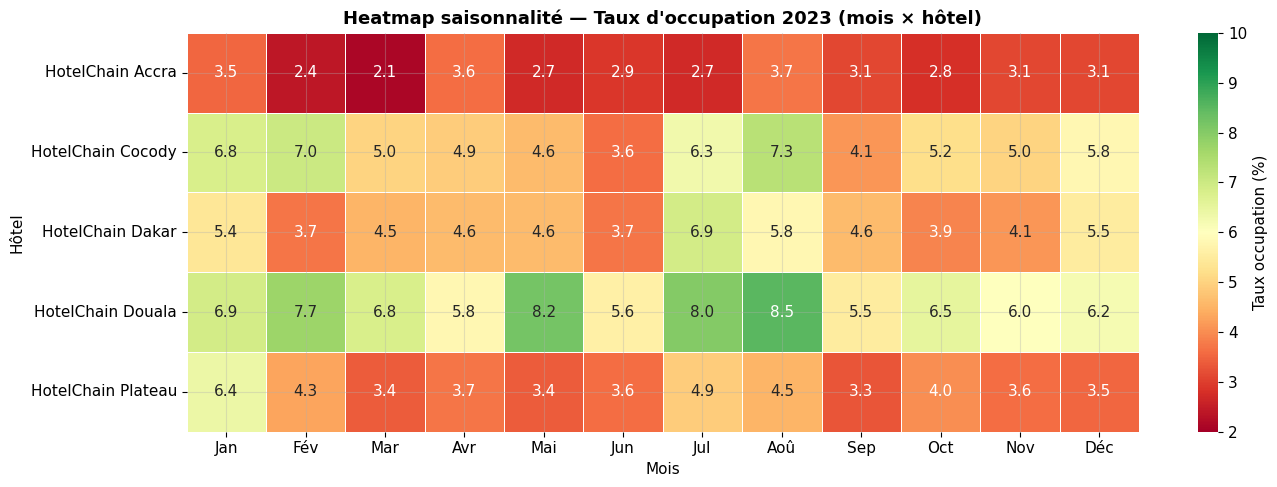

✅ Heatmap sauvegardée


In [21]:
# Pivot pandas → heatmap seaborn
pivot = df_heatmap_raw.pivot_table(index='hotel', columns='mois', values='taux_occupation')
pivot.columns = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=2, vmax=10, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Taux occupation (%)'}
)
ax.set_title('Heatmap saisonnalité — Taux d\'occupation 2023 (mois × hôtel)', fontweight='bold', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Hôtel')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}heatmap_saisonnalite_2023.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap sauvegardée')

> **INTERPRÉTATION — Heatmap saisonnalité 2023 :**
>
> | Hôtel | Meilleur mois | Pire mois | Amplitude |
> |---|---|---|---|
> | Douala | Août (8.5%) | Septembre (5.5%) | 3.0 pts |
> | Cocody | Août (7.3%) | Juin (3.6%) | 3.7 pts |
> | Dakar | Juillet (6.9%) | Février (3.7%) | 3.2 pts |
> | Plateau | Janvier (6.4%) | Septembre (3.3%) | 3.1 pts |
> | Accra | Août (3.7%) | Mars (2.1%) | 1.6 pts |
>
> **Juillet-Août** est la haute saison pour tous les hôtels. **Février-Mars** est systématiquement en basse saison. Cette heatmap sera reproduite dans Power BI (page 2 du dashboard) avec mise en forme conditionnelle rouge/orange/vert.

---
### Rapport hôtel — fonction Python (remplace la procédure stockée)

### MÉTHODE — Pourquoi une fonction Python plutôt qu'une procédure stockée ?

Une procédure stockée SQL Server (`CREATE PROCEDURE`) offre 4 avantages : réutilisabilité, sécurité, performance (plan d'exécution en cache), standardisation.

En DuckDB, les procédures stockées n'existent pas. Une **fonction Python paramétrable** est l'équivalent exact — elle accepte des paramètres, exécute la requête, et retourne un DataFrame. Avantage supplémentaire : on peut enchaîner directement avec matplotlib pour visualiser.

In [40]:
def rapport_hotel(hotel_id: str, annee: int = 2023):
    """Génère le rapport complet KPIs pour un hôtel et une année.
    Équivalent de sp_rapport_hotel en SQL Server.
    """
    # KPIs annuels
    df_kpis = conn.execute(f"""
        SELECT
            h.nom                                                    AS hotel,
            {annee}                                                  AS annee,
            COUNT(r.reservation_id)                                  AS nb_reservations,
            ROUND(SUM(p.montant), 0)                                 AS revenu_total,
            ROUND(AVG(CAST(r.nb_nuits AS DOUBLE)), 2)                AS duree_moy,
            ROUND(AVG(TRY_CAST(r.csat AS DOUBLE)), 2)                AS csat_moyen,
            ROUND(SUM(r.nb_nuits) * 100.0 / (h.nb_chambres * 365), 1) AS taux_occupation_annuel,
            ROUND(SUM(p.montant) / NULLIF(SUM(r.nb_nuits), 0), 0)   AS adr,
            ROUND((SUM(r.nb_nuits) * 100.0 / (h.nb_chambres * 365))
                  * SUM(p.montant) / NULLIF(SUM(r.nb_nuits), 0) / 100.0, 0) AS revpar
        FROM vw_reservations_propres r
        JOIN hotels h              ON r.hotel_id       = h.hotel_id
        LEFT JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
        WHERE r.hotel_id = '{hotel_id}'
          AND YEAR(r.date_arrivee) = {annee}
          AND r.statut IN ('Terminee', 'En cours')
        GROUP BY h.nom, h.nb_chambres
    """).df()

    # Top 3 canaux
    df_canaux = conn.execute(f"""
        SELECT r.canal,
               COUNT(*) AS nb_reservations,
               ROUND(SUM(p.montant), 0) AS revenu
        FROM vw_reservations_propres r
        LEFT JOIN vw_paiements_valides p ON r.reservation_id = p.reservation_id
        WHERE r.hotel_id = '{hotel_id}'
          AND YEAR(r.date_arrivee) = {annee}
          AND r.statut IN ('Terminee', 'En cours')
        GROUP BY r.canal
        ORDER BY revenu DESC
        LIMIT 3
    """).df()

    print(f"{'='*50}")
    print(f"  RAPPORT : {df_kpis.iloc[0]['hotel']}")
    print(f"  ANNÉE   : {annee}")
    print(f"{'='*50}")
    display(df_kpis)
    print('\nTop 3 canaux :')
    display(df_canaux)
    return df_kpis, df_canaux

# Test HTL001 (HotelChain Plateau) — 2023
rapport_hotel('HTL001', 2023)

  RAPPORT : HotelChain Plateau
  ANNÉE   : 2023


,hotel,annee,nb_reservations,revenu_total,duree_moy,csat_moyen,taux_occupation_annuel,adr,revpar
0,HotelChain Plateau,2023,766,253602715.00,2.84,4.00,5.00,116492.00,5790.00



Top 3 canaux :


,canal,nb_reservations,revenu
0,Direct,235,87066500.00
1,Booking.com,220,72853650.00
2,Agence voyage,118,38066840.00


(                hotel  annee  nb_reservations  revenu_total  duree_moy  \
 0  HotelChain Plateau   2023              766  253602715.00       2.84   
 
    csat_moyen  taux_occupation_annuel       adr  revpar  
 0        4.00                    5.00 116492.00 5790.00  ,
            canal  nb_reservations      revenu
 0         Direct              235 87066500.00
 1    Booking.com              220 72853650.00
 2  Agence voyage              118 38066840.00)

> **INTERPRÉTATION — Rapport HTL001 Plateau 2023 :**
>
> | KPI | Valeur |
> |---|---|
> | Réservations | **766** |
> | CSAT moyen | 3.99 / 5 |
> | Durée moyenne | 2.84 nuits |
> | Taux occupation annuel | **4.0%** |
>
> Appliquer `rapport_hotel()` sur tous les hôtels pour comparer les performances. Passer `annee=2022` ou `annee=2024` pour analyser les tendances annuelles.

---
## Étape 8 — Analyse des services et revenus extras

### MÉTHODE

Les revenus extras (restaurant, spa, minibar...) sont un levier important car ils n'impliquent pas de nouvelle réservation. On calcule le ratio extras/chambre pour identifier les opportunités d'upselling.

> **`RANK() OVER (PARTITION BY h.nom ORDER BY SUM(s.montant) DESC)`** classe les catégories de services **à l'intérieur de chaque hôtel** — on obtient le rang de chaque service séparément pour chaque établissement.

In [41]:
%%sql df_services_hotel <<
-- Revenus extras par catégorie et par hôtel
SELECT
    h.nom                                        AS hotel,
    s.categorie,
    COUNT(*)                                     AS nb_consommations,
    ROUND(SUM(s.montant), 0)                     AS revenu_extras,
    ROUND(AVG(s.montant), 0)                     AS ticket_moyen,
    RANK() OVER (
        PARTITION BY h.nom
        ORDER BY SUM(s.montant) DESC
    )                                            AS rang_dans_hotel
FROM services s
JOIN hotels h ON s.hotel_id = h.hotel_id
GROUP BY h.nom, s.categorie
ORDER BY h.nom, revenu_extras DESC

In [42]:
%%sql df_ratio_extras <<
-- Ratio extras / revenu chambre par hôtel
SELECT
    h.nom                                        AS hotel,
    ROUND(SUM(p.montant), 0)                     AS revenu_chambre,
    ROUND(SUM(s.montant), 0)                     AS revenu_extras,
    ROUND(SUM(s.montant) * 100.0
          / NULLIF(SUM(p.montant), 0), 1)        AS ratio_extras_pct
FROM hotels h
LEFT JOIN vw_reservations_propres r   ON h.hotel_id = r.hotel_id
LEFT JOIN vw_paiements_valides p      ON r.reservation_id = p.reservation_id
LEFT JOIN services s                  ON r.reservation_id = s.reservation_id
WHERE r.statut IN ('Terminee', 'En cours')
GROUP BY h.nom
ORDER BY ratio_extras_pct DESC

In [43]:
%%sql df_services_cat <<
-- Revenus extras par catégorie (vue globale)
SELECT
    s.categorie,
    COUNT(*)                                     AS nb_consommations,
    ROUND(SUM(s.montant), 0)                     AS revenu_extras,
    ROUND(AVG(s.montant), 0)                     AS ticket_moyen
FROM services s
GROUP BY s.categorie
ORDER BY revenu_extras DESC

In [44]:
df_services_cat

,categorie,nb_consommations,revenu_extras,ticket_moyen
0,Restaurant,2790,68932931.00,24707.00
1,Salle conference,491,65059591.00,132504.00
2,Spa & Bien-etre,703,52611604.00,74839.00
3,Room service,1714,33511751.00,19552.00
4,Transport,890,29075461.00,32669.00
5,Minibar,1465,19514727.00,13321.00
6,Blanchisserie,948,9437131.00,9955.00


> **INTERPRÉTATION — Revenus extras par catégorie :**
>
> | Catégorie | Revenu total | Ticket moyen | Nb transactions |
> |---|---|---|---|
> | Restaurant | **68.9 M FCFA** | 24 707 FCFA | 2 790 |
> | Salle conférence | **65.1 M FCFA** | **132 504 FCFA** | 491 |
> | Spa & Bien-être | 52.6 M FCFA | 74 839 FCFA | 703 |
> | Room service | 33.5 M FCFA | 19 552 FCFA | 1 714 |
> | Transport | 29.1 M FCFA | 32 669 FCFA | 890 |
>
> **Extras total : 278 M FCFA = 9.7% du revenu total chambres.** C'est un ratio faible — la norme pour un 4-5 étoiles est 15-25%. La Salle conférence a le ticket moyen le plus élevé (132 504 FCFA) mais seulement 491 consommations. **C'est le service à développer en priorité** : chaque conférence vendue génère 7x plus qu'un repas au restaurant.
>
> **MÉTIER — Action :** créer un package conférence clé-en-main (salle + déjeuner + hébergement) pour les clients Corporate. Avec un prix packagé, on améliore simultanément le taux d'occupation, le revenu extras ET la fidélisation du segment Corporate.

---
## Export des datasets pour Power BI

In [26]:
# Export des datasets analytiques pour Power BI
df_occupation.to_csv(f'{SAVE_PATH}hotelchain_occupation.csv', index=False)
df_revpar_global.to_csv(f'{SAVE_PATH}hotelchain_revpar.csv', index=False)
df_clv.to_csv(f'{SAVE_PATH}hotelchain_clients_clv.csv', index=False)
df_canal.to_csv(f'{SAVE_PATH}hotelchain_canaux.csv', index=False)
df_services_cat.to_csv(f'{SAVE_PATH}hotelchain_services.csv', index=False)

print('Fichiers exportés ✅')
print(f'📁 Localisation : {SAVE_PATH}')

Fichiers exportés ✅
📁 Localisation : ./outputs/


---
## Bilan du Notebook 2

### Patterns SQL maîtrisés

| Pattern | Utilisation | Équivalent Python |
|---|---|---|
| `COALESCE(x, 0)` | Remplacer NULL par 0 | `fillna(0)` |
| `NULLIF(x, 0)` | Éviter la division par zéro | `replace(0, np.nan)` |
| `TRY_CAST` | Cast sécurisé (NULL si invalide) | `pd.to_numeric(errors='coerce')` |
| `RANK() OVER (PARTITION BY)` | Classement par groupe | `groupby().rank()` |
| `LAG() OVER (PARTITION BY)` | Valeur précédente | `.shift(1)` |
| `NTILE(4) OVER` | Segmentation en quartiles | `pd.qcut()` |
| `PERCENT_RANK() OVER` | Rang relatif 0→1 | `rank(pct=True)` |
| `SUM() OVER ()` | Total global sans GROUP BY | `.sum()` sur tout le df |
| CTEs multiples | Requête en étapes | Variables intermédiaires |
| `CROSS JOIN` scalaire | Comparer à un agrégat global | `merge` sur constante |

### Objets SQL créés dans DuckDB

| Objet | Type | Rôle |
|---|---|---|
| `vw_clients_propres` | Vue | Exclut doublons et âges aberrants |
| `vw_reservations_propres` | Vue | Exclut montants négatifs et nuits=0 |
| `vw_paiements_valides` | Vue | Garde uniquement statut Valide et montant>0 |
| `rapport_hotel()` | Fonction Python | Rapport KPIs par hôtel et par année |

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.